# 신용카드 채무불이행 예측: SMOTE 비교 실험

이 노트북은 **기본 모델**과 **SMOTE 적용 모델**을 비교하기 위한 실험용 버전이다.

- **Baseline**: StandardScaler → PCA(10) → RandomForestClassifier
- **SMOTE 실험**: SMOTE → StandardScaler → PCA(10) → RandomForestClassifier

## 실험 목적
- 클래스 불균형 데이터에서 SMOTE 적용 전후 성능 차이를 비교한다.
- 특히 **Recall, F1-score, ROC-AUC** 변화를 확인한다.
- 서비스 관점에서 어떤 모델이 더 적합한지 해석한다.

## 주의
- **SMOTE는 학습 데이터에만 적용**한다.
- 테스트 데이터에는 적용하지 않는다.

In [7]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from pathlib import Path

## 1. 데이터 불러오기

In [8]:
DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

xls_path = DATA_DIR / 'UCI_Credit_Card.xls'
csv_path = DATA_DIR / 'UCI_Credit_Card.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

if csv_path.exists():
    df = pd.read_csv(csv_path)
elif xls_path.exists():
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)
else:
    urllib.request.urlretrieve(url, xls_path)
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)

print('원본 데이터 크기 :', df.shape)
df.head()

원본 데이터 크기 : (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. 데이터 점검 및 타깃 정의

In [9]:

print('데이터 크기:', df.shape)
print('컬럼 수:', len(df.columns))
print(df.columns.tolist())

possible_targets = ['default.payment.next.month', 'default payment next month', 'DEFAULT', 'target', 'y']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError('타깃 컬럼을 찾지 못했습니다. target_col을 직접 지정해주세요.')

print('타깃 컬럼:', target_col)

데이터 크기: (30000, 25)
컬럼 수: 25
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']
타깃 컬럼: default payment next month


In [10]:

drop_candidates = ['ID', 'id']
feature_df = df.drop(columns=[c for c in drop_candidates if c in df.columns]).copy()

X = feature_df.drop(columns=[target_col]).copy()
y = feature_df[target_col].copy()

print('X shape:', X.shape)
print('\ny 분포')
print(y.value_counts())
print('\ny 비율')
print(y.value_counts(normalize=True).round(4))

X shape: (30000, 23)

y 분포
default payment next month
0    23364
1     6636
Name: count, dtype: int64

y 비율
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## 3. EDA

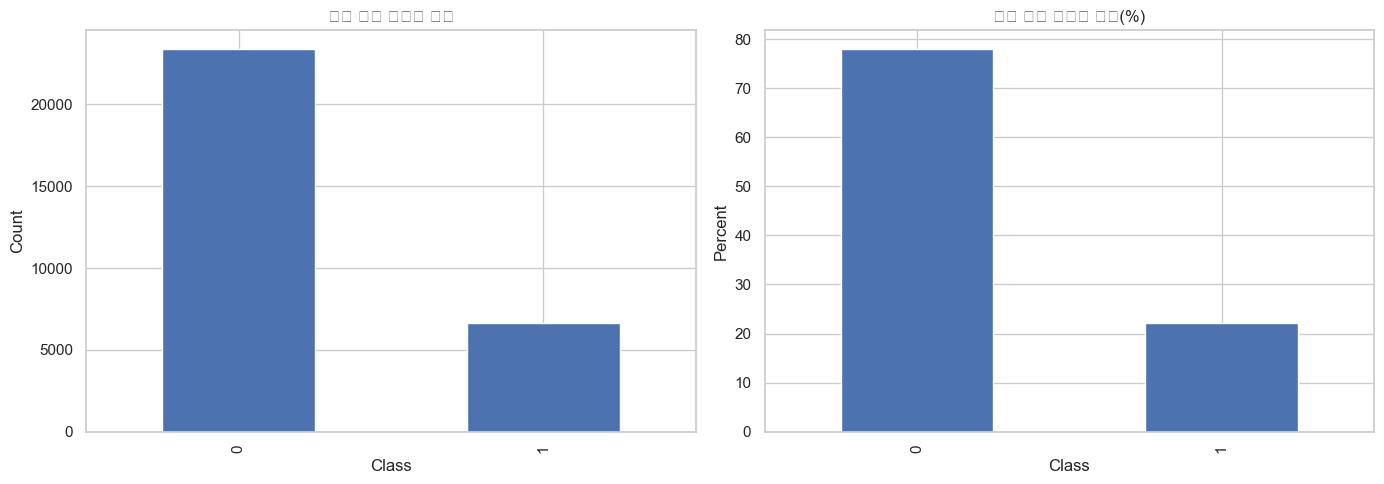

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('연체 여부 클래스 분포')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

(y.value_counts(normalize=True).sort_index() * 100).plot(kind='bar', ax=axes[1])
axes[1].set_title('연체 여부 클래스 비율(%)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percent')

plt.tight_layout()
plt.show()

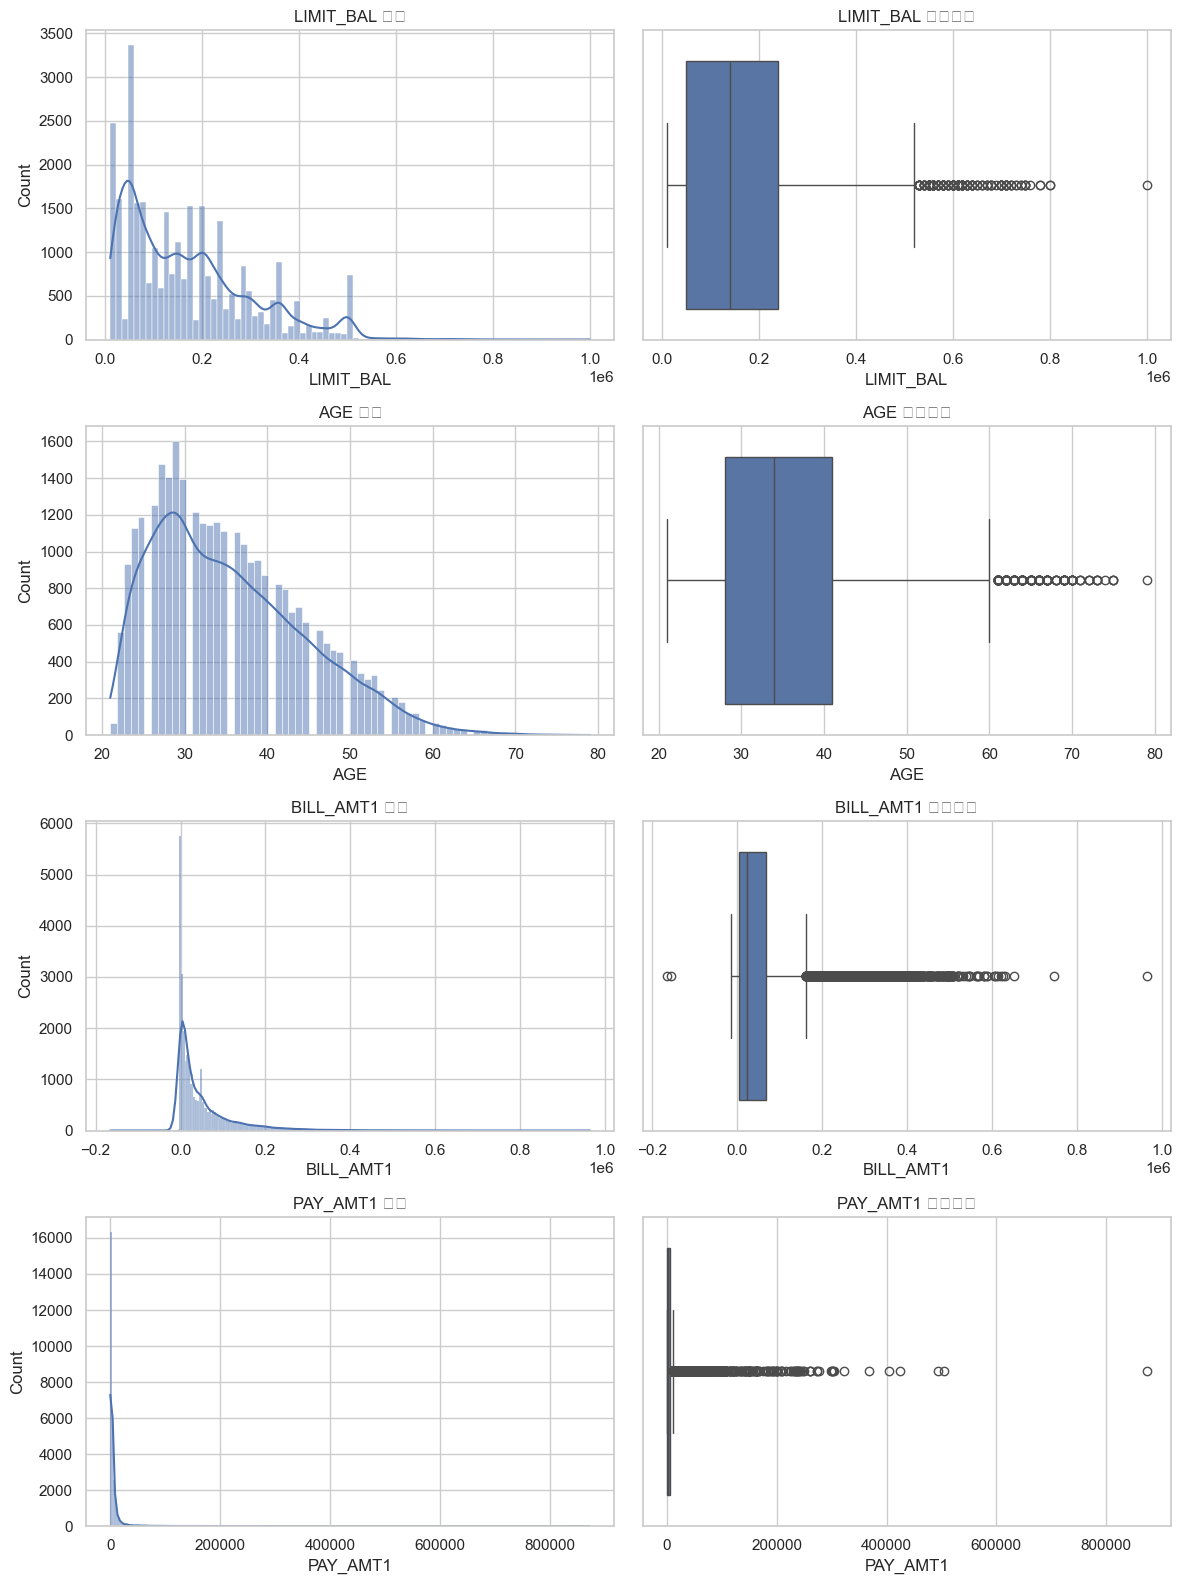

In [12]:

num_cols = X.select_dtypes(include=np.number).columns.tolist()
display_cols = [c for c in ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1'] if c in X.columns]
if len(display_cols) == 0:
    display_cols = num_cols[:4]

fig, axes = plt.subplots(len(display_cols), 2, figsize=(12, 4 * len(display_cols)))
if len(display_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(display_cols):
    sns.histplot(X[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} 분포')

    sns.boxplot(x=X[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} 박스플롯')

plt.tight_layout()
plt.show()

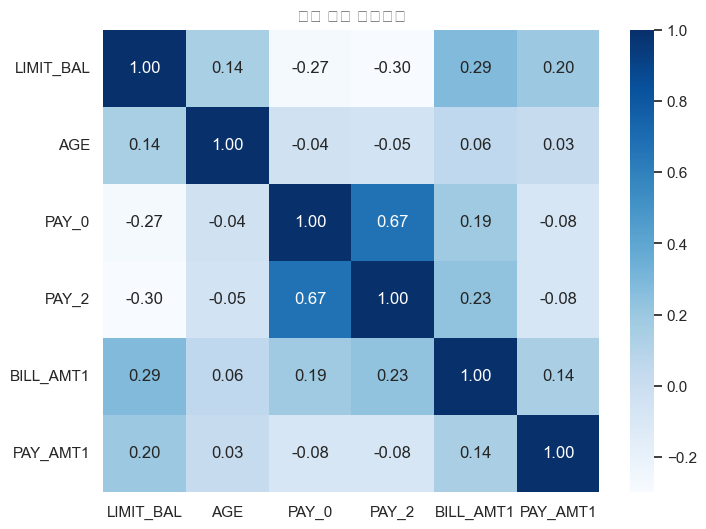

In [13]:

corr_cols = [c for c in ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1'] if c in X.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(8, 6))
    sns.heatmap(X[corr_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
    plt.title('주요 변수 상관관계')
    plt.show()

## 4. 데이터 전처리 및 Train/Test Split

In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)
print('\nTrain 클래스 비율')
print(y_train.value_counts(normalize=True).round(4))
print('\nTest 클래스 비율')
print(y_test.value_counts(normalize=True).round(4))

Train shape: (24000, 23) (24000,)
Test shape : (6000, 23) (6000,)

Train 클래스 비율
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Test 클래스 비율
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [15]:

numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42))
])

## 5. Baseline 모델 학습

In [16]:

baseline_model = Pipeline([
    ('preprocessor', numeric_preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

In [17]:

def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }

baseline_metrics = get_metrics(y_test, baseline_pred, baseline_proba)
pd.DataFrame([baseline_metrics], index=['Baseline'])

,Accuracy,Precision,Recall,F1,ROC_AUC
Baseline,0.799333,0.587983,0.309721,0.405726,0.739183


## 6. SMOTE 적용 모델 학습

SMOTE는 **학습 데이터에만** 적용한다.  
`imblearn.pipeline.Pipeline`을 사용해 데이터 누수를 방지한다.

In [18]:

smote_model = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

smote_model.fit(X_train, y_train)
smote_pred = smote_model.predict(X_test)
smote_proba = smote_model.predict_proba(X_test)[:, 1]

In [19]:

smote_metrics = get_metrics(y_test, smote_pred, smote_proba)
comparison_df = pd.DataFrame([baseline_metrics, smote_metrics], index=['Baseline', 'SMOTE'])
comparison_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Baseline,0.799333,0.587983,0.309721,0.405726,0.739183
SMOTE,0.761000,0.462030,0.490580,0.475877,0.733974


## 7. 모델 평가 및 시각화

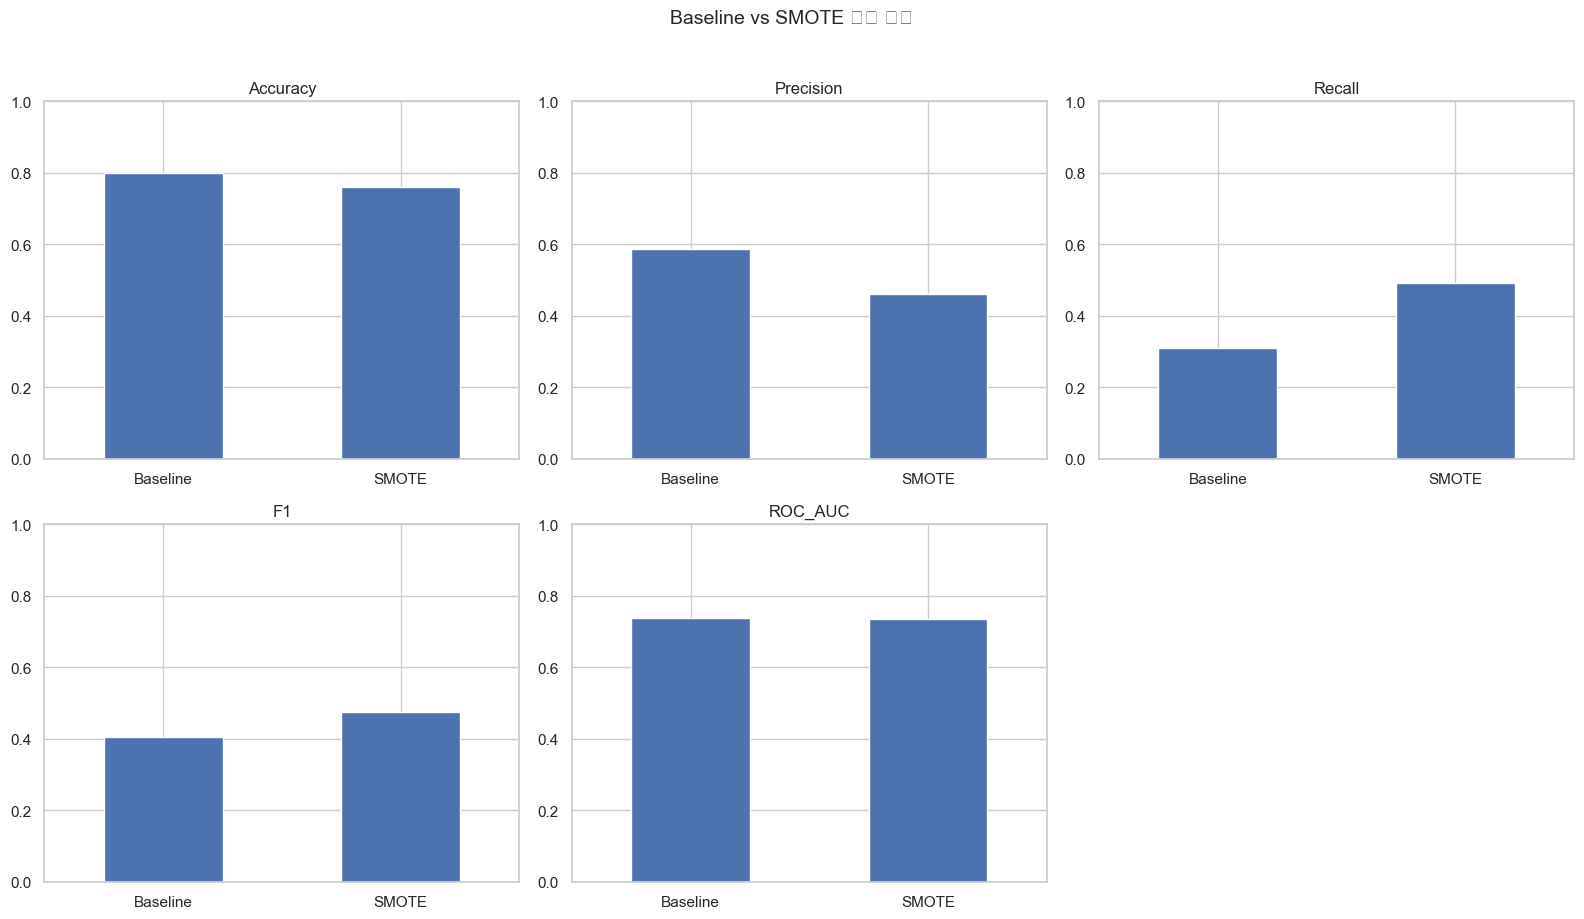

In [20]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

for idx, metric in enumerate(metrics_to_plot):
    r, c = divmod(idx, 3)
    comparison_df[metric].plot(kind='bar', ax=axes[r, c], rot=0)
    axes[r, c].set_title(metric)
    axes[r, c].set_ylim(0, 1)

axes[1, 2].axis('off')
plt.suptitle('Baseline vs SMOTE 성능 비교', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

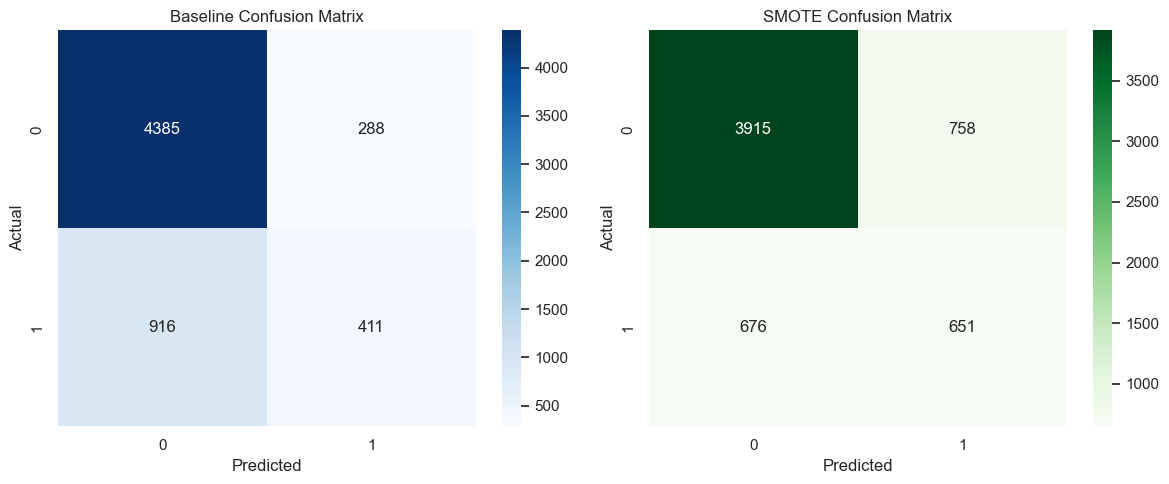

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, baseline_pred)
cm_smote = confusion_matrix(y_test, smote_pred)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SMOTE Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

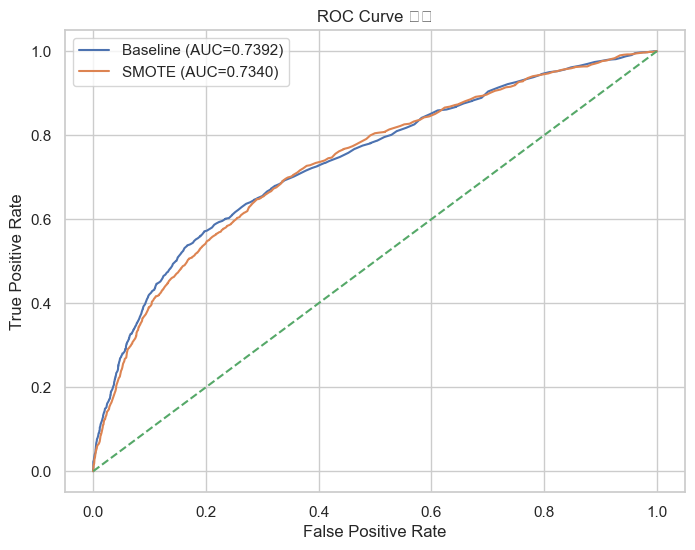

In [22]:

fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_smote, tpr_smote, _ = roc_curve(y_test, smote_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC={baseline_metrics["ROC_AUC"]:.4f})')
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (AUC={smote_metrics["ROC_AUC"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve 비교')
plt.legend()
plt.show()

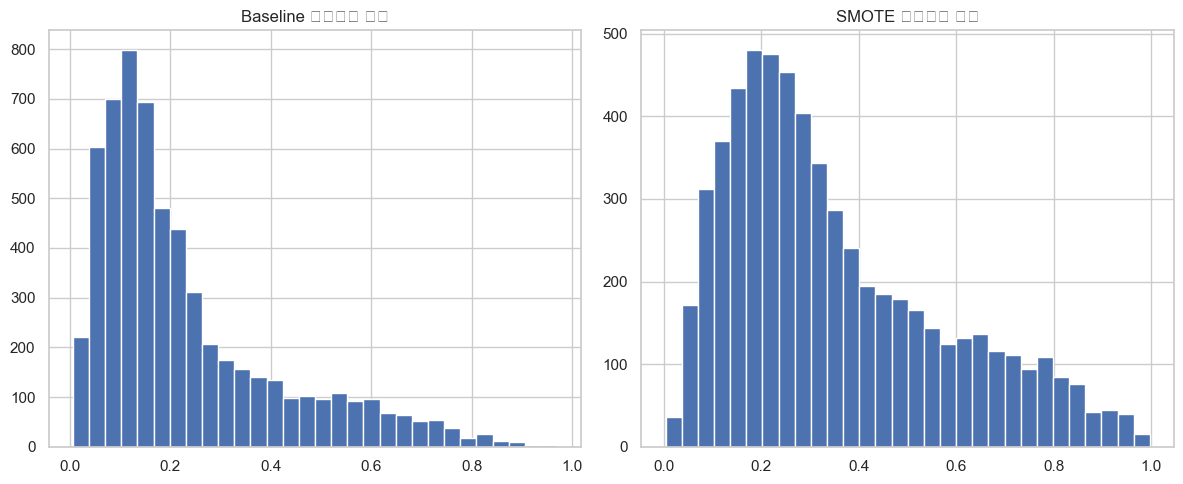

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(baseline_proba, bins=30)
axes[0].set_title('Baseline 예측확률 분포')
axes[1].hist(smote_proba, bins=30)
axes[1].set_title('SMOTE 예측확률 분포')
plt.tight_layout()
plt.show()

## 8. 교차검증 비교

In [24]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

baseline_cv = cross_validate(
    baseline_model, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

smote_cv = cross_validate(
    smote_model, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

cv_df = pd.DataFrame({
    'Baseline': {k.replace('test_', '').upper(): np.mean(v) for k, v in baseline_cv.items() if k.startswith('test_')},
    'SMOTE': {k.replace('test_', '').upper(): np.mean(v) for k, v in smote_cv.items() if k.startswith('test_')}
}).T

cv_df

,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
Baseline,0.80325,0.606264,0.315879,0.415276,0.740494
SMOTE,0.76850,0.477882,0.500657,0.488957,0.731223


## 9. 피처 중요도

PCA를 거친 뒤에는 원본 변수 중요도를 바로 읽기 어렵다.  
그래서 테스트셋 기준 **Permutation Importance**로 근사 중요도를 확인한다.

In [25]:

perm = permutation_importance(
    baseline_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
5,PAY_0,0.039021
6,PAY_2,0.023981
9,PAY_5,0.012473
17,PAY_AMT1,0.012020
8,PAY_4,0.010996
7,PAY_3,0.010722
0,LIMIT_BAL,0.010353
2,EDUCATION,0.007301
10,PAY_6,0.006957
18,PAY_AMT2,0.006901


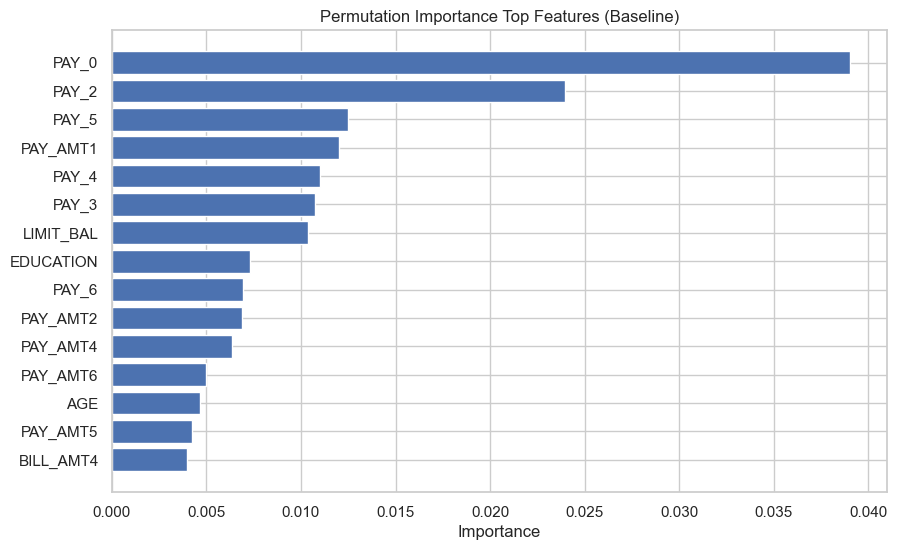

In [26]:

top_n = min(15, len(importance_df))
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['feature'].head(top_n)[::-1],
    importance_df['importance'].head(top_n)[::-1]
)
plt.title('Permutation Importance Top Features (Baseline)')
plt.xlabel('Importance')
plt.show()

## 10. SMOTE 모델 하이퍼파라미터 튜닝

In [27]:

param_dist = {
    'smote__sampling_strategy': [0.4, 0.6, 0.8, 1.0],
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [None, 5, 10, 15],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None]
}

smote_tune_model = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    estimator=smote_tune_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print('Best Params:')
print(random_search.best_params_)
print('\nBest CV ROC-AUC:', random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params:
{'smote__sampling_strategy': 0.4, 'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': None, 'clf__max_depth': 10}

Best CV ROC-AUC: 0.7535664936934856


In [28]:

best_smote_model = random_search.best_estimator_
best_smote_pred = best_smote_model.predict(X_test)
best_smote_proba = best_smote_model.predict_proba(X_test)[:, 1]

best_smote_metrics = get_metrics(y_test, best_smote_pred, best_smote_proba)

final_compare_df = pd.DataFrame(
    [baseline_metrics, smote_metrics, best_smote_metrics],
    index=['Baseline', 'SMOTE', 'SMOTE_Tuned']
)

final_compare_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Baseline,0.799333,0.587983,0.309721,0.405726,0.739183
SMOTE,0.761000,0.462030,0.490580,0.475877,0.733974
SMOTE_Tuned,0.799667,0.571922,0.374529,0.452641,0.754821


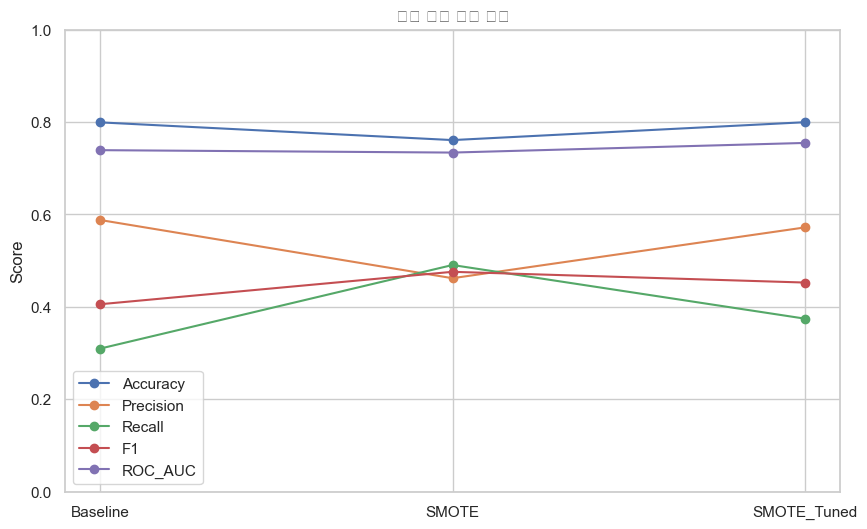

In [29]:

plt.figure(figsize=(10, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
    plt.plot(final_compare_df.index, final_compare_df[metric], marker='o', label=metric)

plt.ylim(0, 1)
plt.title('최종 모델 성능 비교')
plt.ylabel('Score')
plt.legend()
plt.show()

## 11. 결과 해석 가이드

### Baseline이 더 나은 경우
- Accuracy, Precision, ROC-AUC가 전반적으로 높다
- 과도한 오탐을 줄이는 것이 중요하다

### SMOTE가 더 나은 경우
- Recall이 의미 있게 상승한다
- 연체 고객을 놓치는 비용이 더 크다

### 서비스 관점
- 금융 심사에서는 **False Negative**를 줄이는 것도 중요하다
- 그래서 Recall과 ROC-AUC 개선이 있으면 SMOTE를 긍정적으로 볼 수 있다
- 다만 Precision 하락과 오탐 증가도 함께 확인해야 한다

## 12. 모델 저장

In [30]:

import joblib

final_model = best_smote_model  # 필요시 baseline_model 또는 smote_model로 변경
joblib.dump(final_model, 'credit_pipeline_smote.pkl')
print('저장 완료: credit_pipeline_smote.pkl')

저장 완료: credit_pipeline_smote.pkl
